<a href="https://colab.research.google.com/github/sanjay-sj87/deep-learning/blob/main/11MTCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import zipfile
import os

zip_file_path = "/content/actors.zip"

extract_dir = "."

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(os.path.abspath(extract_dir))

/content


In [3]:
!pip install mtcnn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 41.9 MB/s eta 0:00:00


In [4]:
import cv2
from mtcnn.mtcnn import MTCNN

In [5]:
detector = MTCNN()

In [6]:
image = cv2.imread("/content/actors/12.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


In [7]:
result = detector.detect_faces(image_rgb)

In [8]:
for face in result:
  x, y, w, h = face['box']
  cv2.rectangle(image_rgb, (x, y), (x + w, y + h), (0, 255, 0), 2)

(np.float64(-0.5), np.float64(2999.5), np.float64(1999.5), np.float64(-0.5))

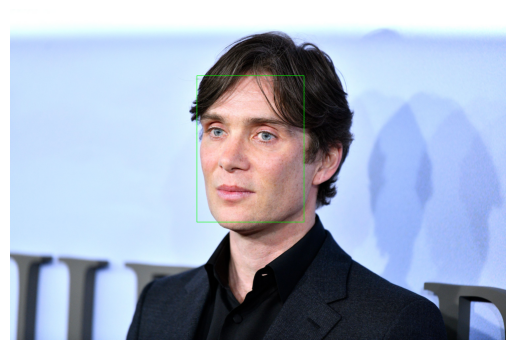

In [9]:
plt.imshow(image_rgb)
plt.axis('off')

Found 1 face(s).


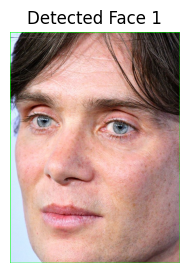

In [10]:
if result:
    print(f"Found {len(result)} face(s).")
    for i, face in enumerate(result):
        x, y, w, h = face['box']
        cropped_face = image_rgb[y:y+h, x:x+w]

        plt.figure(figsize=(3, 3))
        plt.imshow(cropped_face)
        plt.title(f'Detected Face {i+1}')
        plt.axis('off')
        plt.show()
else:
    print("No faces detected in the image.")

In [11]:
detector = MTCNN()

In [19]:
from google.colab import files
uploaded = files.upload()

Saving actors.zip to actors (2).zip


In [21]:
import os
import shutil

# Create the img_folder if it doesn't exist
if not os.path.exists("img_folder"):
    os.makedirs("img_folder")

# List all files in the current directory and move .jpg files to img_folder
for file_name in os.listdir("."):
    if file_name.lower().endswith(".jpg"):
        shutil.move(file_name, os.path.join("img_folder", file_name))
print("Moved all .jpg files to img_folder.")

Moved all .jpg files to img_folder.


In [22]:
import os

folder_path = "img_folder" # Corrected path

for img in os.listdir(folder_path):
    print(img)

5.jpg
15.jpg
14.jpg
12.jpg
11.jpg
2.jpg
13.jpg
image.jpg
3.jpg
4.jpg


In [28]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

MessageError: Error: credential propagation was unsuccessful

In [39]:
!rm -rf img_folder

In [40]:
!unzip img_folder.zip

unzip:  cannot find or open img_folder.zip, img_folder.zip.zip or img_folder.zip.ZIP.


In [42]:
!ls

 actors		  'actors (2).zip'   newfolder
'actors (1).zip'   actors.zip	     sample_data


In [43]:
!ls img_folder

ls: cannot access 'img_folder': No such file or directory


In [44]:
import os

folder_path = "/content/img_folder"

for img in os.listdir(folder_path):
    print(img)

FileNotFoundError: [Errno 2] No such file or directory: '/content/img_folder'

In [36]:
import os

print(os.path.isfile("/content/img_folder"))  # True = file ❌
print(os.path.isdir("/content/img_folder"))   # True = folder ✅

False
True


In [37]:
arr = cv2.imread("img_folder/" + img)

In [26]:
import os

# Create the newfolder if it doesn't exist
if not os.path.exists("newfolder"):
    os.makedirs("newfolder")
print("Created 'newfolder' directory.")

Created 'newfolder' directory.


In [27]:
for img in os.listdir("img_folder"):
    arr = cv2.imread("img_folder/"+ img)
    results=detector.detect_faces(arr)
    if results:
      x,y,width,height=results[0]['box']
      x1,y1=max(0,x),max(0,y)
      x2,y2=x1+width,y1+height

      face_crop = arr[y1:y2, x1:x2]
      cv2.imwrite('newfolder/'+img,face_crop)

In [29]:
from torchvision import transforms,datasets


In [30]:
transfo=transforms.Compose([transforms.Resize((224,224))])

In [31]:
import os
import shutil

os.makedirs("img_folder/faces", exist_ok=True)

for file in os.listdir("img_folder"):
    if file.endswith(".jpg"):
        shutil.move("img_folder/" + file, "img_folder/faces/" + file)

In [32]:
imgtensors=datasets.ImageFolder("img_folder",transform=transfo)

In [33]:
import os
import cv2

ls = []

folder_path = "img_folder/faces"

for img in os.listdir(folder_path):
    path = folder_path + "/" + img
    arr = cv2.imread(path)
    arr = cv2.resize(arr, (224, 224))
    ls.append(arr)

print("Total images loaded:", len(ls))

Total images loaded: 10


In [34]:
newar=np.stack(ls,axis=0)

In [35]:
newar.shape

(10, 224, 224, 3)